# 04 — Grid Search : Pondération optimale du score géopolitique

**Objectif** : Trouver la combinaison `(w_sum, w_smoothed)` qui maximise la corrélation de **Spearman**
entre un score géopolitique hybride et l'ampleur de la réaction du WTI à la réouverture du marché.

- `geo_score_raw_sum` : tension brute cumulée pendant la fermeture (capte les pics)
- `geo_score_raw_smoothed` : tension moyenne par tranche 15 min (intensité normalisée)
- Cible : `|Variation_Pct|` (amplitude du choc, indépendamment du sens)

In [1]:
# ═══════════════════════════════════════════════
# Cellule 1 — Imports
# ═══════════════════════════════════════════════
import io
import os

import boto3
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep", font_scale=1.1)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
# ═══════════════════════════════════════════════
# Cellule 2 — Chargement & préparation
# ═══════════════════════════════════════════════

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Lecture du Parquet Gold (dossier Spark) ──
prefix = "combined/stress_index/"
objs = s3.list_objects_v2(Bucket="datalake", Prefix=prefix)
parquet_keys = [o["Key"] for o in objs.get("Contents", []) if o["Key"].endswith(".parquet")]

dfs = []
for key in parquet_keys:
    resp = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(resp["Body"].read()), engine="pyarrow"))

df_gold = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f"Table Gold chargée : {df_gold.shape[0]:,} lignes × {df_gold.shape[1]} colonnes")

# ── Vérification que geo_score_raw_max est disponible ──
if "geo_score_raw_max" not in df_gold.columns:
    raise ValueError(
        "❌ La colonne 'geo_score_raw_max' est absente de la table Gold.\n"
        "   → Relancez le pipeline compute_stress_index.py après avoir ajouté\n"
        "     F.col('geo_score_raw_max') dans le select final."
    )
print("✅ 'geo_score_raw_max' présente dans la table Gold\n")

# ── Déduplication par Datetime ──────────────────────────────────
# Le Gold est explosé (1 ligne par pays acteur) : plusieurs lignes
# partagent le même Datetime, geo_score_raw_max et Variation_Pct.
# On déduplique avant la grid search pour ne pas biaiser Spearman.
cols_metric = ["Datetime", "gap_duration_15m",
               "geo_score_raw_max", "geo_score_raw_sum",
               "geo_score_raw_smoothed", "Variation_Pct"]
df_unique = df_gold[cols_metric].drop_duplicates(subset=["Datetime"])
print(f"Lignes uniques par Datetime : {len(df_unique):,} / {len(df_gold):,} total\n")

# ── Filtrage : bougies de réouverture uniquement ──
# (gap > 1 : seules ces bougies ont max ≠ mean, l'ALPHA est donc pertinente)
df_reopen = df_unique[df_unique["gap_duration_15m"] > 1].copy()
print(f"Bougies de réouverture : {len(df_reopen):,} / {len(df_unique):,} "
      f"({len(df_reopen)/len(df_unique)*100:.1f}%)\n")

# ── Reconstruction de la moyenne : mean = sum / gap ──
df_reopen["geo_score_raw_mean"] = (
    df_reopen["geo_score_raw_sum"] / df_reopen["gap_duration_15m"]
)

# ── Aperçu des variables clés ──
cols_focus = ["Datetime", "gap_duration_15m",
              "geo_score_raw_max", "geo_score_raw_mean",
              "geo_score_raw_smoothed", "Variation_Pct"]
print("Aperçu statistique :")
df_reopen[cols_focus].describe().round(4)

Table Gold chargée : 5,389 lignes × 21 colonnes
✅ 'geo_score_raw_max' présente dans la table Gold

Lignes uniques par Datetime : 3,532 / 5,389 total

Bougies de réouverture : 44 / 3,532 (1.2%)

Aperçu statistique :


,Datetime,gap_duration_15m,geo_score_raw_max,geo_score_raw_mean,geo_score_raw_smoothed,Variation_Pct
count,44,44.0000,44.0000,44.0000,44.0000,43.0000
mean,2026-02-01 00:35:47.727272960,47.8182,28548.0015,11913.8999,25221.1812,0.1198
min,2026-01-04 23:00:00,5.0000,12775.4818,5118.3629,11795.3608,-3.3323
25%,2026-01-15 17:00:00,5.0000,21800.9307,9773.7568,19648.0565,-0.1458
50%,2026-01-31 11:00:00,5.0000,26812.2692,12363.8083,24082.5199,-0.0462
75%,2026-02-16 06:52:30,53.5000,32413.1283,14039.1280,27473.9039,0.1225
max,2026-03-02 23:00:00,220.0000,88925.5976,29216.3682,74319.2955,7.7872
std,NaN,76.4029,12750.3631,4304.4960,10708.3980,1.3802


In [3]:
# ═══════════════════════════════════════════════
# Cellule 3 — Grid Search sur ALPHA
# ═══════════════════════════════════════════════
# Cherche alpha optimal dans : alpha*max + (1-alpha)*mean
# Maximise la corrélation de Spearman avec Variation_Pct

alphas = np.arange(0.0, 1.001, 0.05).round(4)
results = []

# Nettoyage : supprimer les lignes avec NaN sur les colonnes nécessaires
df_clean = df_reopen[
    ["geo_score_raw_max", "geo_score_raw_mean", "Variation_Pct"]
].dropna()
print(f"Lignes valides pour le Grid Search : {len(df_clean):,}\n")

for alpha in alphas:
    # Score hybride : alpha × max + (1-alpha) × mean
    hybrid = (
        alpha * df_clean["geo_score_raw_max"]
        + (1 - alpha) * df_clean["geo_score_raw_mean"]
    )

    # Corrélation de Spearman (robuste aux non-linéarités et outliers)
    rho, p_value = stats.spearmanr(hybrid, df_clean["Variation_Pct"])

    results.append({
        "alpha": alpha,
        "spearman_rho": rho,
        "abs_rho": abs(rho),
        "p_value": p_value,
    })

df_results = pd.DataFrame(results)
print(f"Grid Search terminé : {len(df_results)} valeurs d'alpha testées")
print(f"ALPHA actuel dans le pipeline : 0.80  →  ρ = {df_results.loc[df_results['alpha']==0.80, 'spearman_rho'].values[0]:.4f}")
df_results

Lignes valides pour le Grid Search : 43

Grid Search terminé : 21 valeurs d'alpha testées
ALPHA actuel dans le pipeline : 0.80  →  ρ = 0.1127


,alpha,spearman_rho,abs_rho,p_value
0,0.0000,0.1542,0.1542,0.3235
1,0.0500,0.1692,0.1692,0.2782
2,0.1000,0.1477,0.1477,0.3445
3,0.1500,0.1630,0.1630,0.2964
4,0.2000,0.1689,0.1689,0.2791
5,0.2500,0.1772,0.1772,0.2557
6,0.3000,0.1738,0.1738,0.2649
7,0.3500,0.1402,0.1402,0.3700
8,0.4000,0.1485,0.1485,0.3420
9,0.4500,0.1352,0.1352,0.3874


In [4]:
# ═══════════════════════════════════════════════
# Cellule 4 — Résultats optimaux
# ═══════════════════════════════════════════════

best = df_results.loc[df_results["abs_rho"].idxmax()]
current_alpha_rho = df_results.loc[df_results["alpha"] == 0.80, "spearman_rho"].values[0]

print("=" * 60)
print("  CALIBRATION OPTIMALE DE L'ALPHA")
print("=" * 60)
print(f"  ALPHA optimal                : {best['alpha']:.2f}")
print(f"  (1 - ALPHA) → poids mean    : {1 - best['alpha']:.2f}")
print(f"  Spearman ρ optimal           : {best['spearman_rho']:.4f}")
print(f"  Spearman ρ actuel (α=0.80)   : {current_alpha_rho:.4f}")
gain = best["abs_rho"] - abs(current_alpha_rho)
print(f"  Gain vs. valeur actuelle     : {gain:+.4f}")
print(f"  p-value                      : {best['p_value']:.2e}")
print("=" * 60)

signif = "✅ Statistiquement significatif (p < 0.05)" if best["p_value"] < 0.05 else "⚠️  Non significatif (p ≥ 0.05)"
print(f"\n  {signif}")

print(f"\n  → Remplacer dans compute_stress_index.py :")
print(f"    ALPHA = 0.8   →   ALPHA = {best['alpha']:.2f}")

# ── Top 5 ──
print("\n── Top 5 des ALPHA ──")
df_results.sort_values("abs_rho", ascending=False).head(5)[["alpha", "spearman_rho", "p_value"]]

  CALIBRATION OPTIMALE DE L'ALPHA
  ALPHA optimal                : 0.25
  (1 - ALPHA) → poids mean    : 0.75
  Spearman ρ optimal           : 0.1772
  Spearman ρ actuel (α=0.80)   : 0.1127
  Gain vs. valeur actuelle     : +0.0645
  p-value                      : 2.56e-01

  ⚠️  Non significatif (p ≥ 0.05)

  → Remplacer dans compute_stress_index.py :
    ALPHA = 0.8   →   ALPHA = 0.25

── Top 5 des ALPHA ──


,alpha,spearman_rho,p_value
5,0.2500,0.1772,0.2557
6,0.3000,0.1738,0.2649
1,0.0500,0.1692,0.2782
4,0.2000,0.1689,0.2791
3,0.1500,0.1630,0.2964


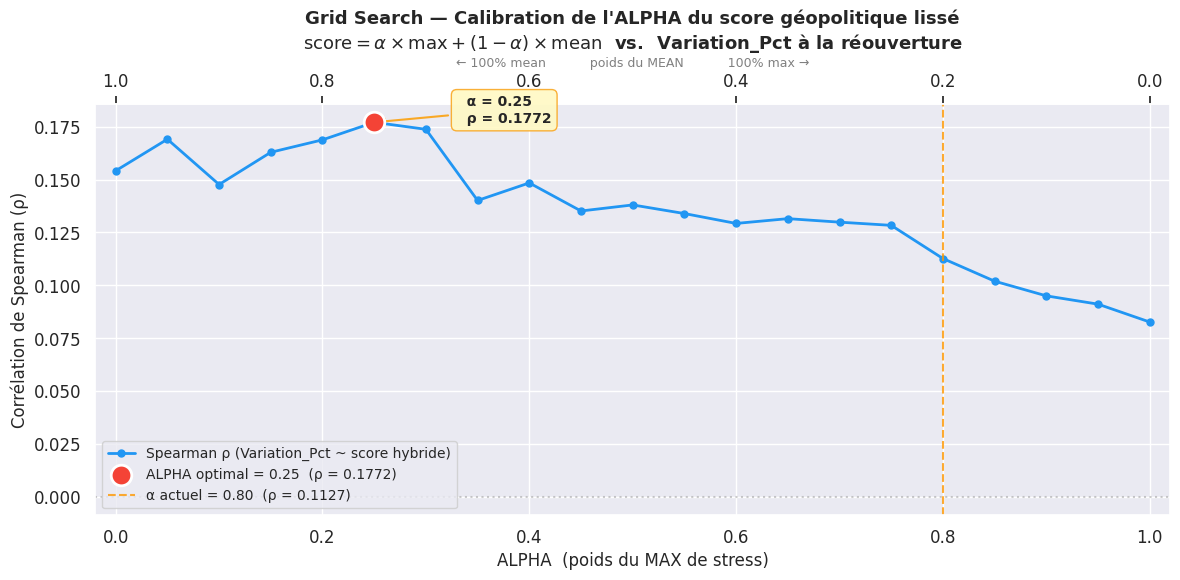

In [5]:
# ═══════════════════════════════════════════════
# Cellule 5 — Visualisation
# ═══════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

# Courbe de corrélation
ax.plot(
    df_results["alpha"],
    df_results["spearman_rho"],
    marker="o",
    linewidth=2,
    markersize=5,
    color="#2196F3",
    label="Spearman ρ (Variation_Pct ~ score hybride)",
    zorder=2,
)

# Point optimal
ax.scatter(
    best["alpha"],
    best["spearman_rho"],
    s=220,
    color="#F44336",
    edgecolors="white",
    linewidths=2,
    zorder=4,
    label=f"ALPHA optimal = {best['alpha']:.2f}  (ρ = {best['spearman_rho']:.4f})",
)

# Valeur actuelle hardcodée (0.8)
ax.axvline(x=0.80, color="#FF9800", linestyle="--", linewidth=1.5, alpha=0.8,
           label=f"α actuel = 0.80  (ρ = {current_alpha_rho:.4f})")

# Annotation du point optimal
offset = 0.08 if best["alpha"] < 0.85 else -0.18
ax.annotate(
    f"  α = {best['alpha']:.2f}\n  ρ = {best['spearman_rho']:.4f}",
    xy=(best["alpha"], best["spearman_rho"]),
    xytext=(best["alpha"] + offset, best["spearman_rho"]),
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="#FFF9C4", ec="#F9A825", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color="#F9A825", lw=1.5),
)

ax.axhline(y=0, color="grey", linestyle=":", alpha=0.4)

ax.set_xlabel("ALPHA  (poids du MAX de stress)", fontsize=12)
ax.set_ylabel("Corrélation de Spearman (ρ)", fontsize=12)
ax.set_title(
    "Grid Search — Calibration de l'ALPHA du score géopolitique lissé\n"
    r"$\text{score} = \alpha \times \text{max} + (1-\alpha) \times \text{mean}$  "
    "vs.  Variation_Pct à la réouverture",
    fontsize=13,
    fontweight="bold",
)

# Axe secondaire
ax2 = ax.secondary_xaxis("top")
ax2.set_xlabel("← 100% mean           poids du MEAN           100% max →", fontsize=9, color="grey")
ticks = np.arange(0, 1.1, 0.2)
ax2.set_xticks(ticks)
ax2.set_xticklabels([f"{1-t:.1f}" for t in ticks])

ax.legend(loc="lower left", fontsize=10)
ax.set_xlim(-0.02, 1.02)
plt.tight_layout()
plt.show()